# Stage 2 Pipeline Storyboard

This short notebook summarizes the Stage 2 multi-pair labeling run and surfaces the resulting artifacts.

## What Stage 2 does
- Reads configs from `configs/labeling_stage2.yaml` and `configs/paths_stage2.yaml`
- Discovers symbols that match the pattern (default `*USDT`) and fetches OHLCV via `HistoryLoader`
- Pools 1-candle returns to derive global alpha/beta thresholds
- Reuses the Stage 1 labeling pipeline per (symbol, backW, forW)
- Writes processed candles, datasets, and JSON reports under `stage1/stage2_data`
- Generates charts in `data/charts_stage2` via `notebooks/stage2_hold_extremes.ipynb`


In [11]:
# %pip install pandas pyarrow matplotlib seaborn pyyaml

In [12]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict

import pandas as pd
import yaml

try:
    from IPython.display import Image, display
    HAS_IPY = True
except ImportError:  # pragma: no cover - optional in non-notebook runs
    HAS_IPY = False
    Image = None
    display = None

pd.options.display.max_rows = 120


In [13]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "configs").exists() else NOTEBOOK_DIR.parent
LABEL_CFG_PATH = PROJECT_ROOT / "configs" / "labeling_stage2.yaml"
PATH_CFG_PATH = PROJECT_ROOT / "configs" / "paths_stage2.yaml"
OUTPUT_DIR = PROJECT_ROOT / "data" / "charts_stage2"


def load_yaml(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"Missing config: {path}")
    with path.open("r", encoding="utf-8") as handle:
        payload = yaml.safe_load(handle) or {}
    if not isinstance(payload, dict):
        raise ValueError(f"Expected mapping in {path}, got {type(payload).__name__}")
    return payload


def load_reports(report_dir: Path) -> pd.DataFrame:
    records = []
    for path in sorted(report_dir.glob("*.json")):
        with path.open("r", encoding="utf-8") as handle:
            payload = json.load(handle)
        counts = payload.get("counts", {})
        dist = payload.get("distribution", {})
        record = {
            "symbol": payload.get("symbol"),
            "interval": payload.get("interval"),
            "backW": int(payload.get("backW", 0)),
            "forW": int(payload.get("forW", 0)),
            "alpha": float(payload.get("alpha", 0.0)),
            "beta": float(payload.get("beta", 0.0)),
            "dataset_path": payload.get("dataset_path"),
            "n_valid": int(payload.get("n_valid", 0)),
            "n_total": int(payload.get("n_total", 0)),
            "buy": int(counts.get("BUY", 0)),
            "hold": int(counts.get("HOLD", 0)),
            "sell": int(counts.get("SELL", 0)),
            "nan": int(counts.get("NaN", 0)),
            "share_buy": float(dist.get("BUY", 0.0)),
            "share_hold": float(dist.get("HOLD", 0.0)),
            "share_sell": float(dist.get("SELL", 0.0)),
        }
        record["window"] = f"backW{record['backW']}_forW{record['forW']}"
        records.append(record)
    df = pd.DataFrame(records)
    if df.empty:
        raise FileNotFoundError(f"No JSON reports found in {report_dir}")
    return df


label_cfg = load_yaml(LABEL_CFG_PATH)
paths_cfg = load_yaml(PATH_CFG_PATH)

REPORTS_DIR = (PROJECT_ROOT / paths_cfg["reports_dir"]).expanduser().resolve()
DATASETS_DIR = (PROJECT_ROOT / paths_cfg["datasets_dir"]).expanduser().resolve()
PROCESSED_DIR = (PROJECT_ROOT / paths_cfg["processed_dir"]).expanduser().resolve()

report_df = load_reports(REPORTS_DIR)
report_df.head()


,symbol,interval,backW,forW,alpha,beta,dataset_path,n_valid,n_total,buy,hold,sell,nan,share_buy,share_hold,share_sell,window
0,0GUSDT,4h,1,1,0.041944,0.203349,/home/kamil/binance-bot/stage1/stage2_data/dat...,524,524,44,383,97,0,0.083969,0.730916,0.185115,backW1_forW1
1,0GUSDT,4h,1,2,0.041944,0.223684,/home/kamil/binance-bot/stage1/stage2_data/dat...,523,523,62,339,122,0,0.118547,0.648184,0.233270,backW1_forW2
2,0GUSDT,4h,1,3,0.041944,0.244019,/home/kamil/binance-bot/stage1/stage2_data/dat...,522,522,66,294,162,0,0.126437,0.563218,0.310345,backW1_forW3
3,0GUSDT,4h,1,4,0.041944,0.264354,/home/kamil/binance-bot/stage1/stage2_data/dat...,521,521,64,269,188,0,0.122841,0.516315,0.360845,backW1_forW4
4,0GUSDT,4h,1,5,0.041944,0.284689,/home/kamil/binance-bot/stage1/stage2_data/dat...,520,520,59,243,218,0,0.113462,0.467308,0.419231,backW1_forW5


## Stage 2 outputs at a glance

In [14]:
summary = pd.DataFrame([{
    "symbols": report_df["symbol"].nunique(),
    "windows": report_df["window"].nunique(),
    "rows": len(report_df),
    "total_labels": int(report_df[["buy", "hold", "sell"]].sum().sum()),
    "avg_hold_share": report_df["share_hold"].mean(),
    "median_hold_share": report_df["share_hold"].median(),
}])
summary


,symbols,windows,rows,total_labels,avg_hold_share,median_hold_share
0,436,25,10881,75778016,0.733428,0.735297


## Visual highlights
If the charts are missing, run `notebooks/stage2_hold_extremes.ipynb` to regenerate `data/charts_stage2`.


Stage 2 label mix overview


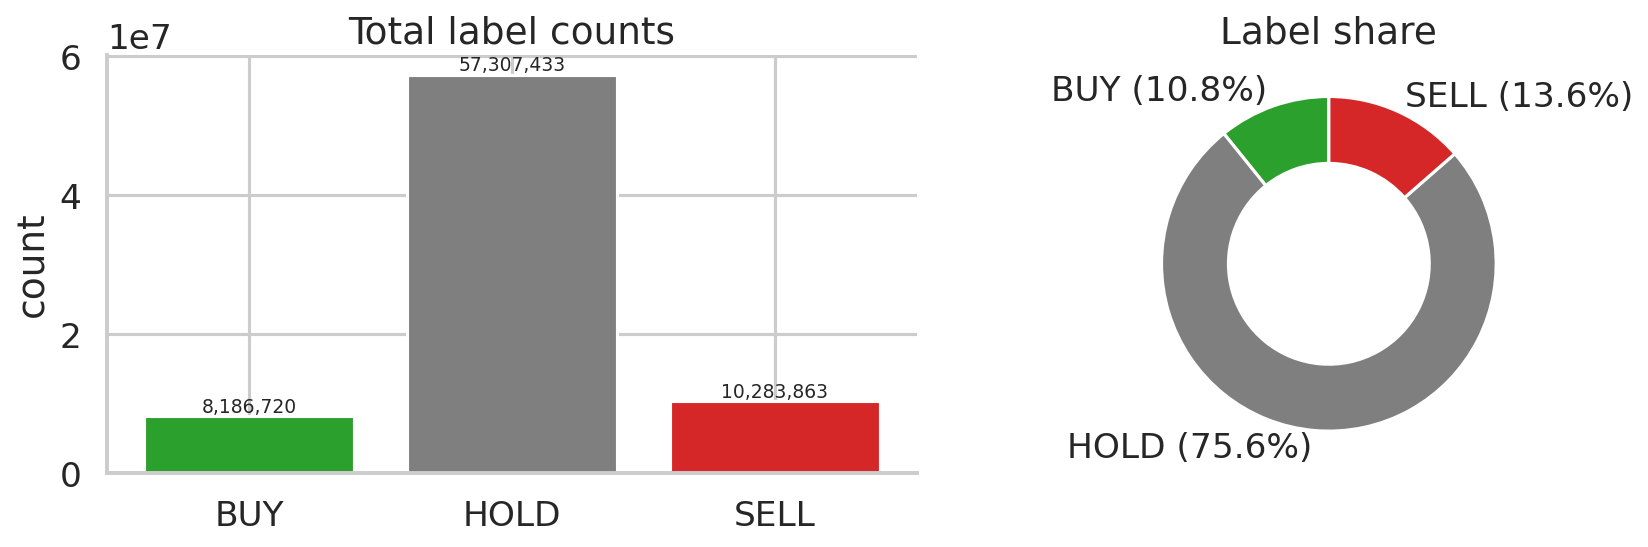

Labeled rows over time


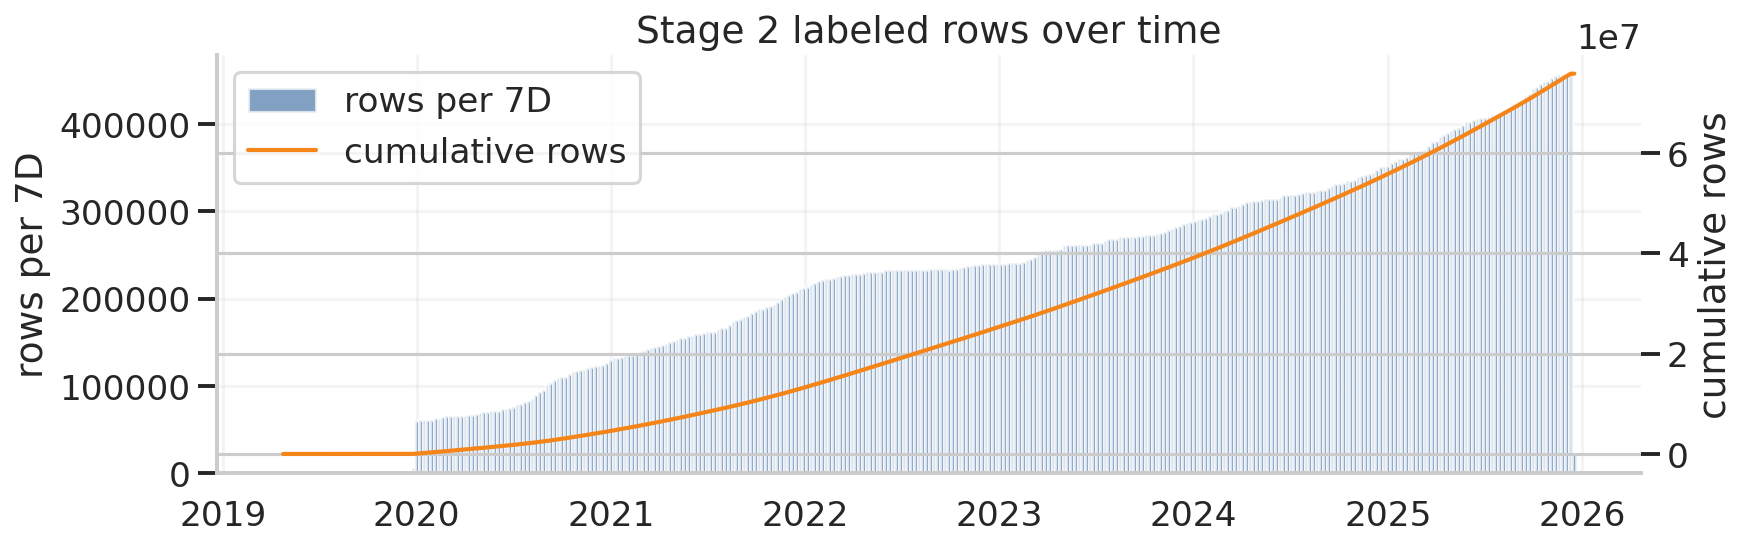

HOLD share distribution


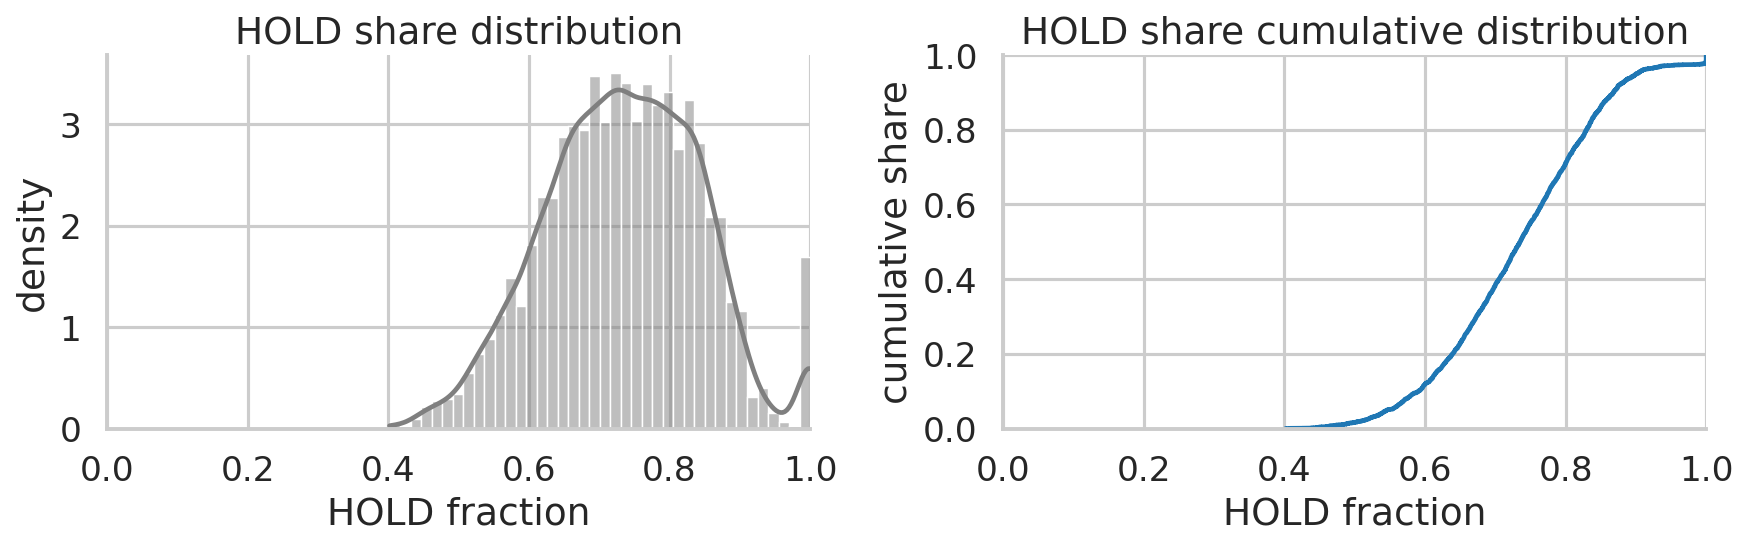

HOLD share by window


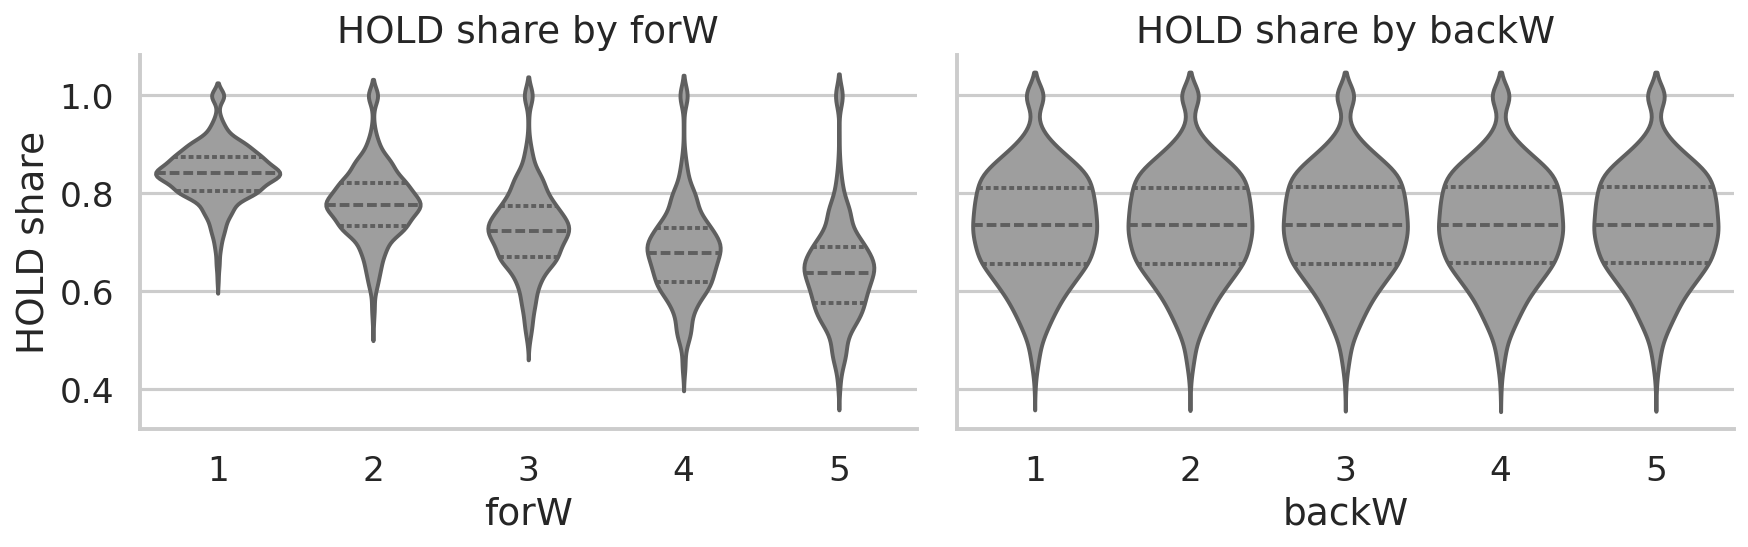

BUY/HOLD/SELL heatmaps


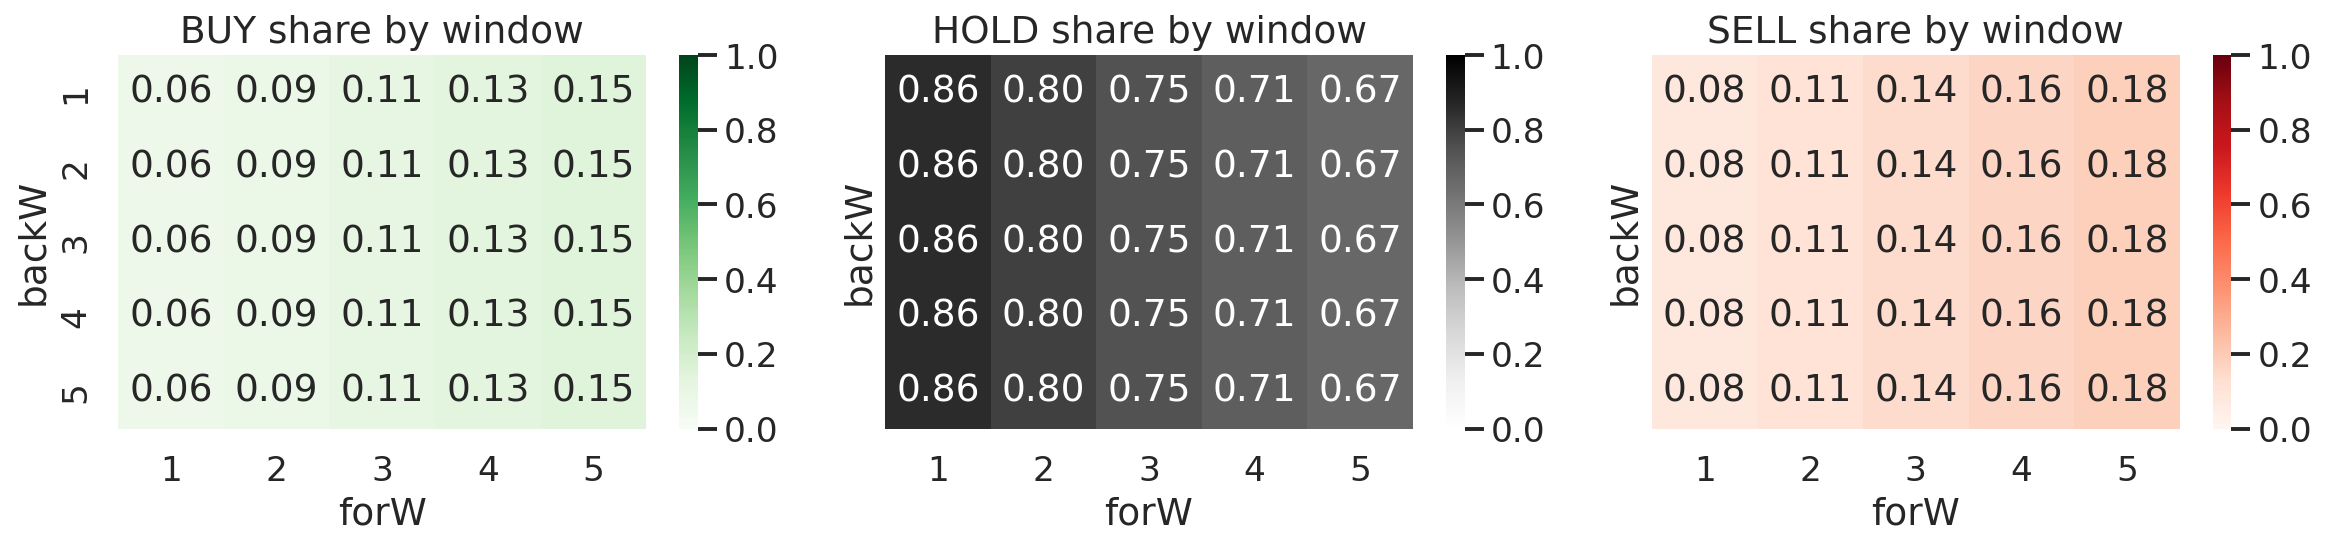

Label mix for top symbols


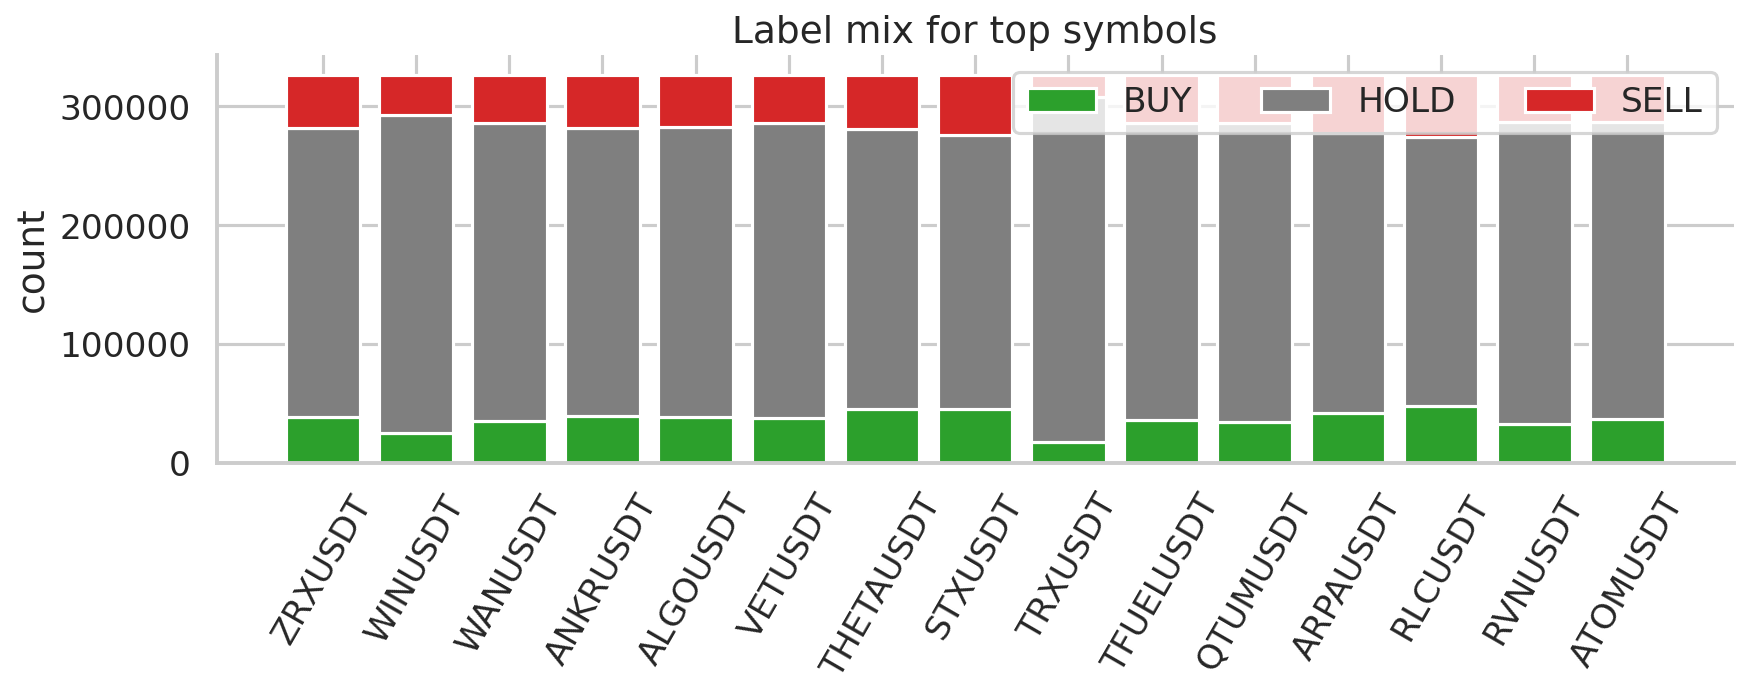

Alpha percentile sensitivity


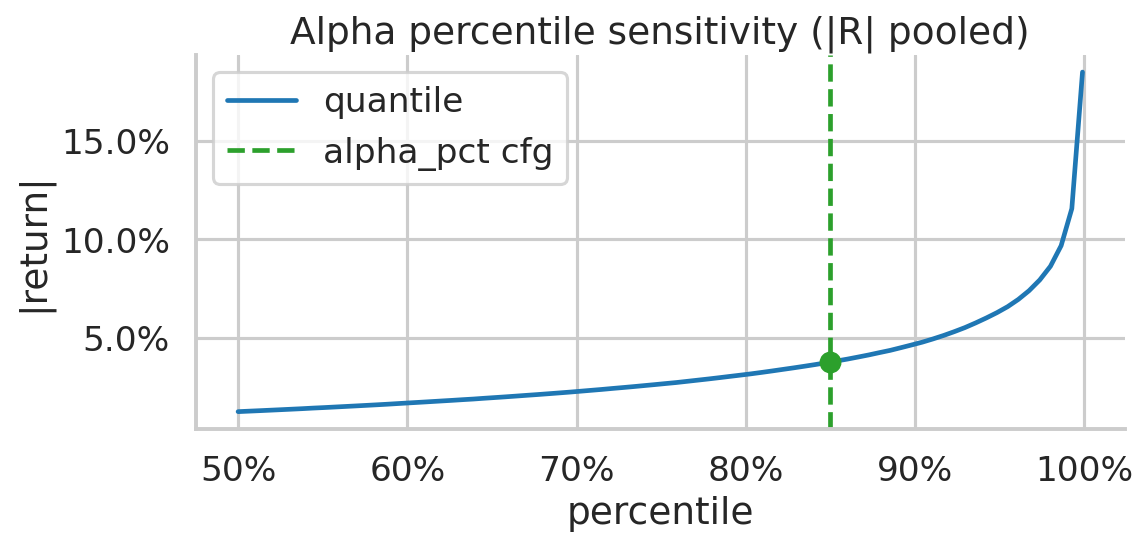

Beta percentile sensitivity


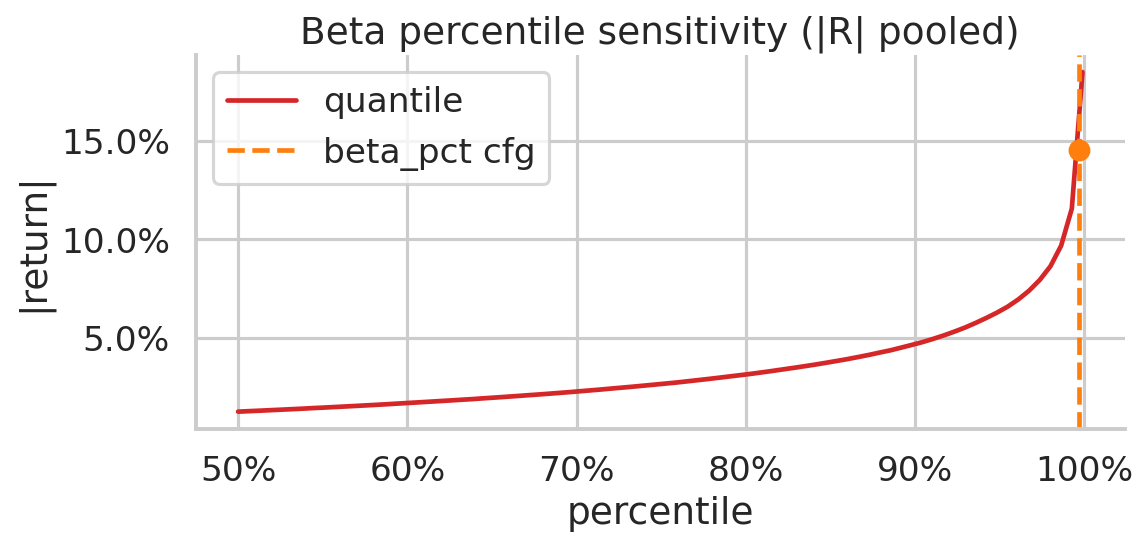

Forward return distributions


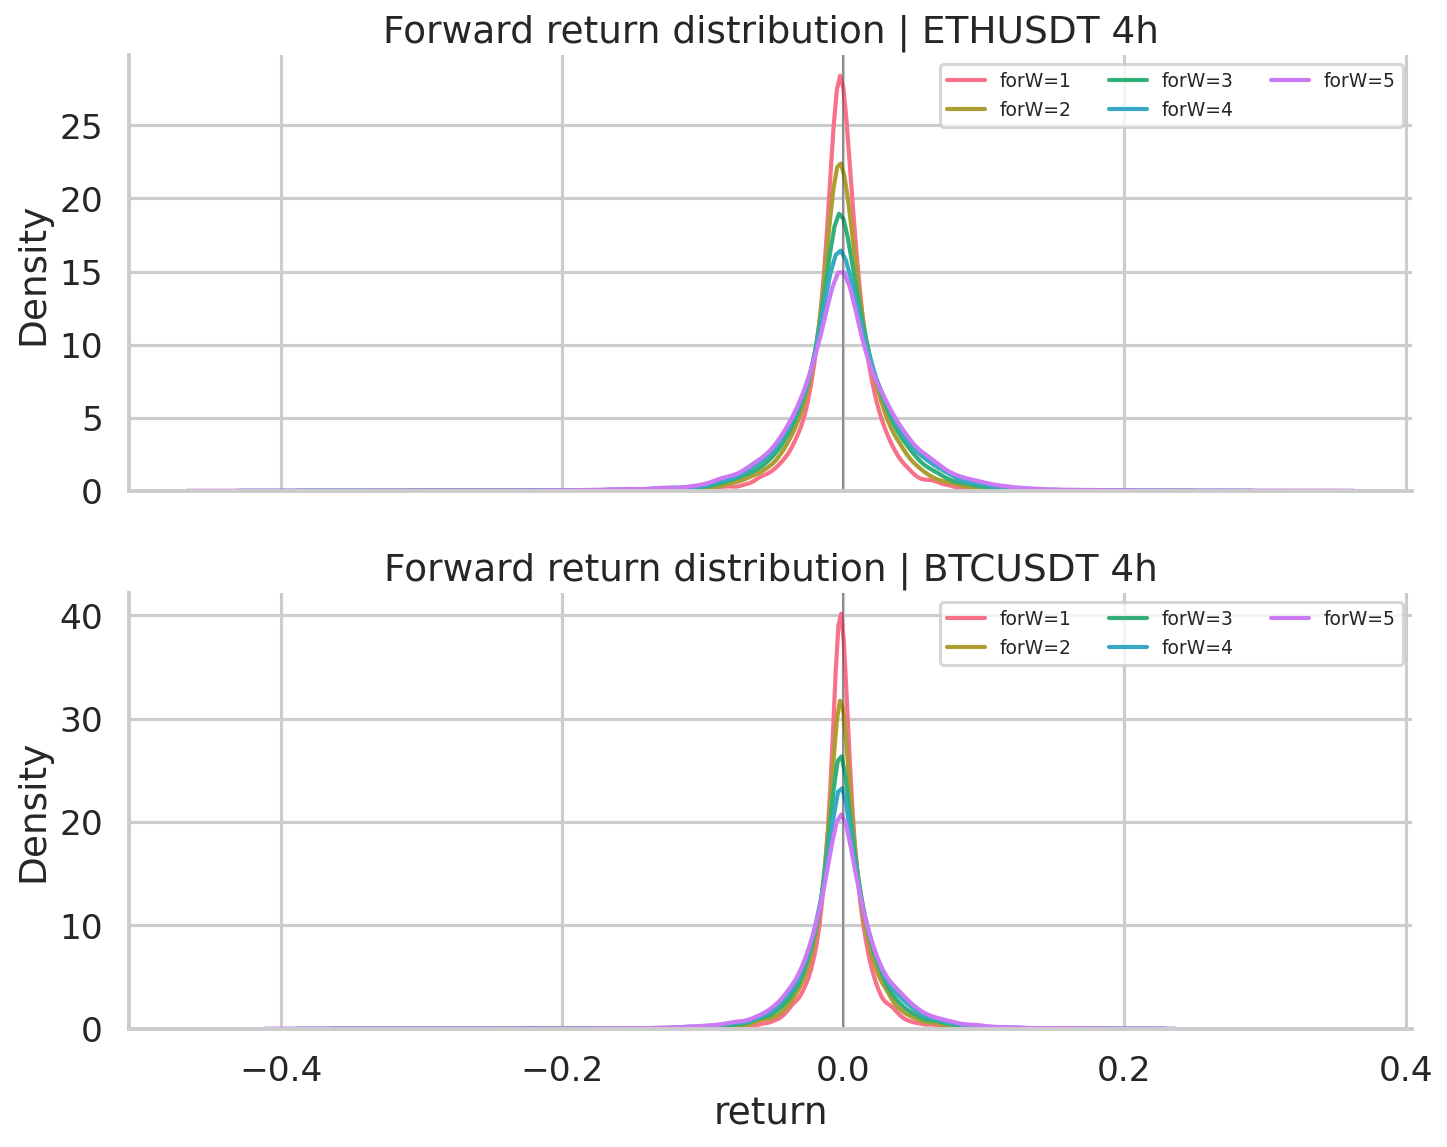

Tail curve of |forward returns|


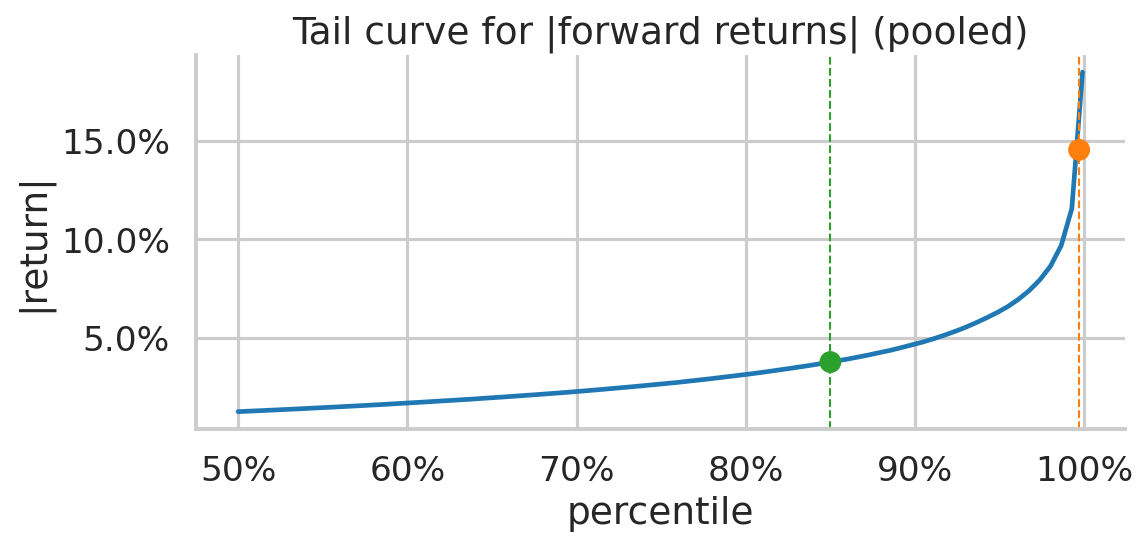

Video visual: return distribution


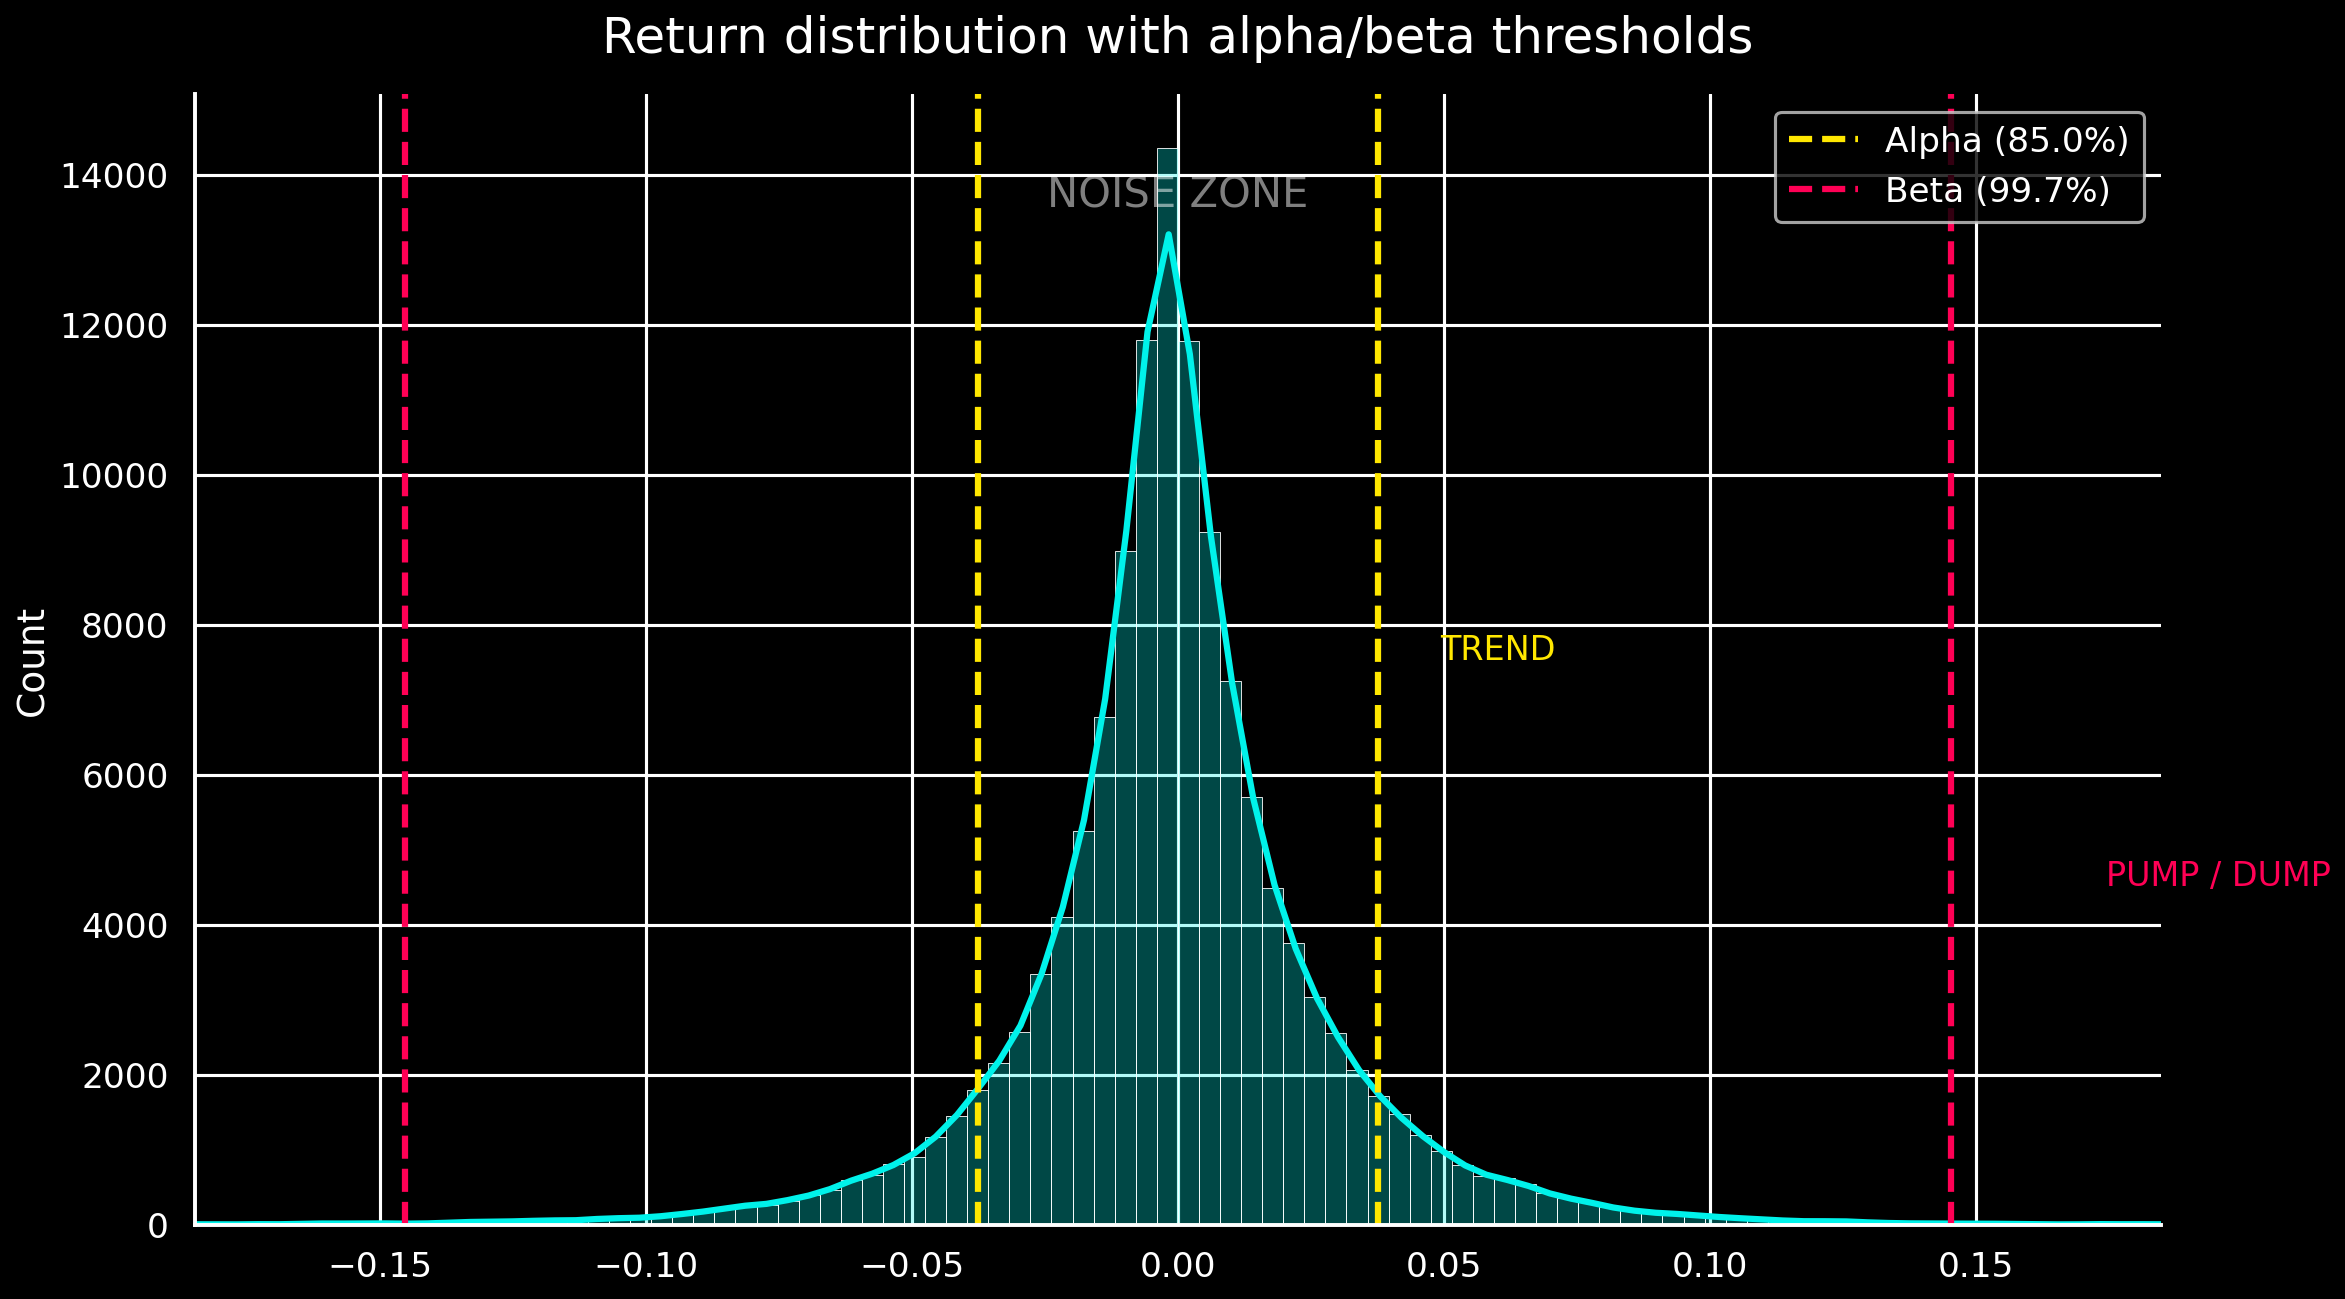

Video visual: labeling logic


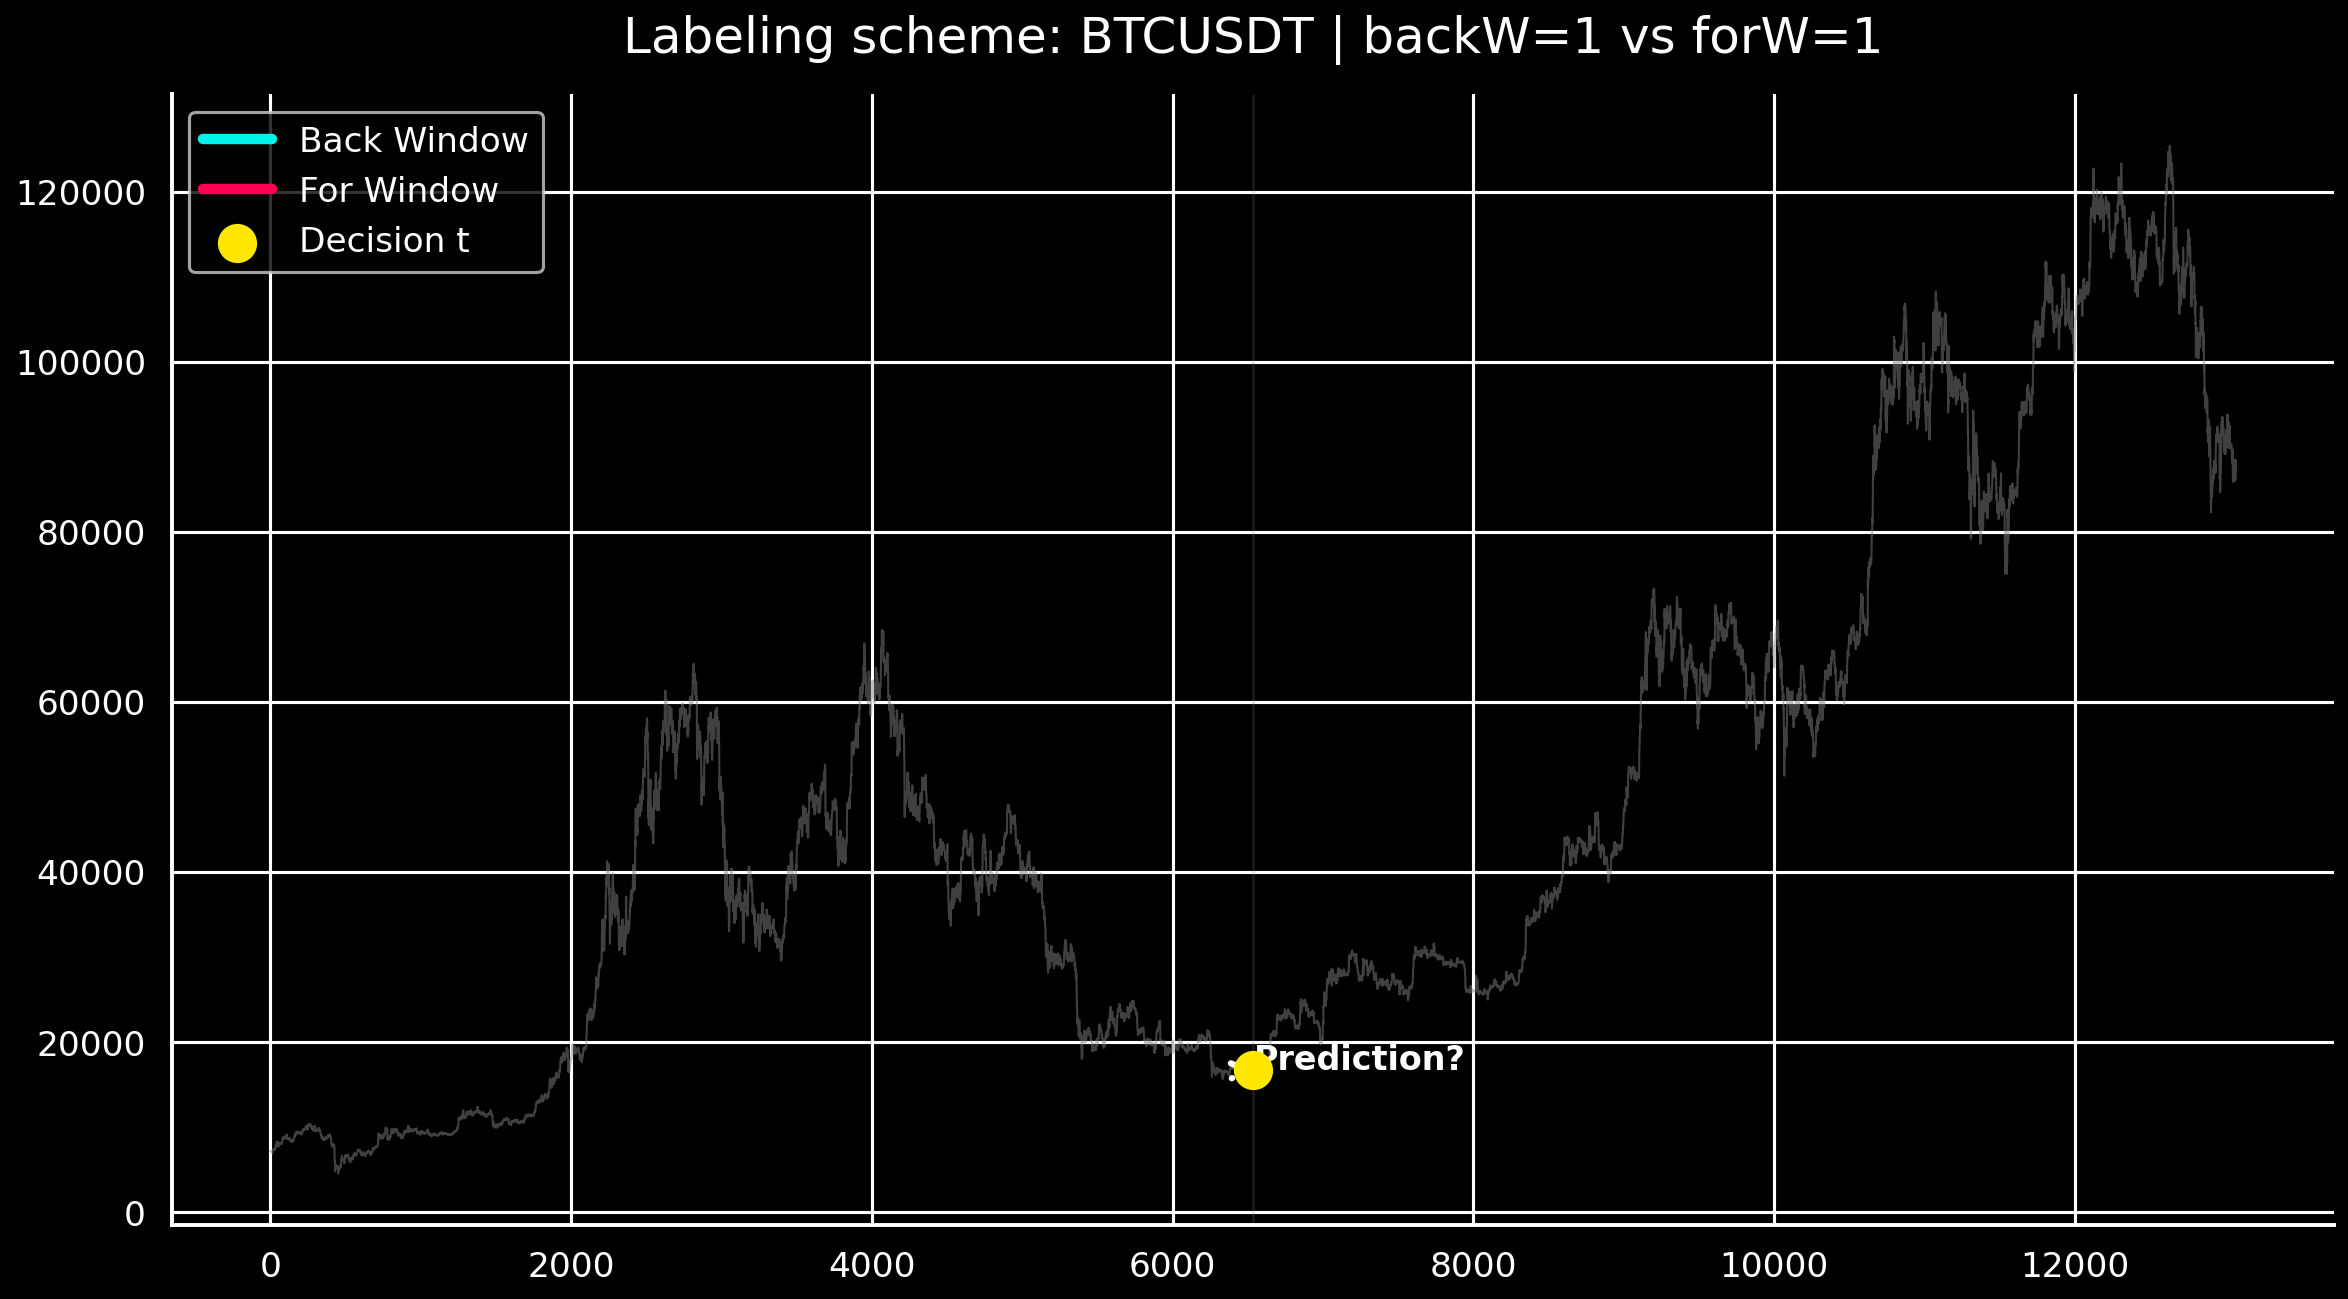

Video visual: Stage 2 scale


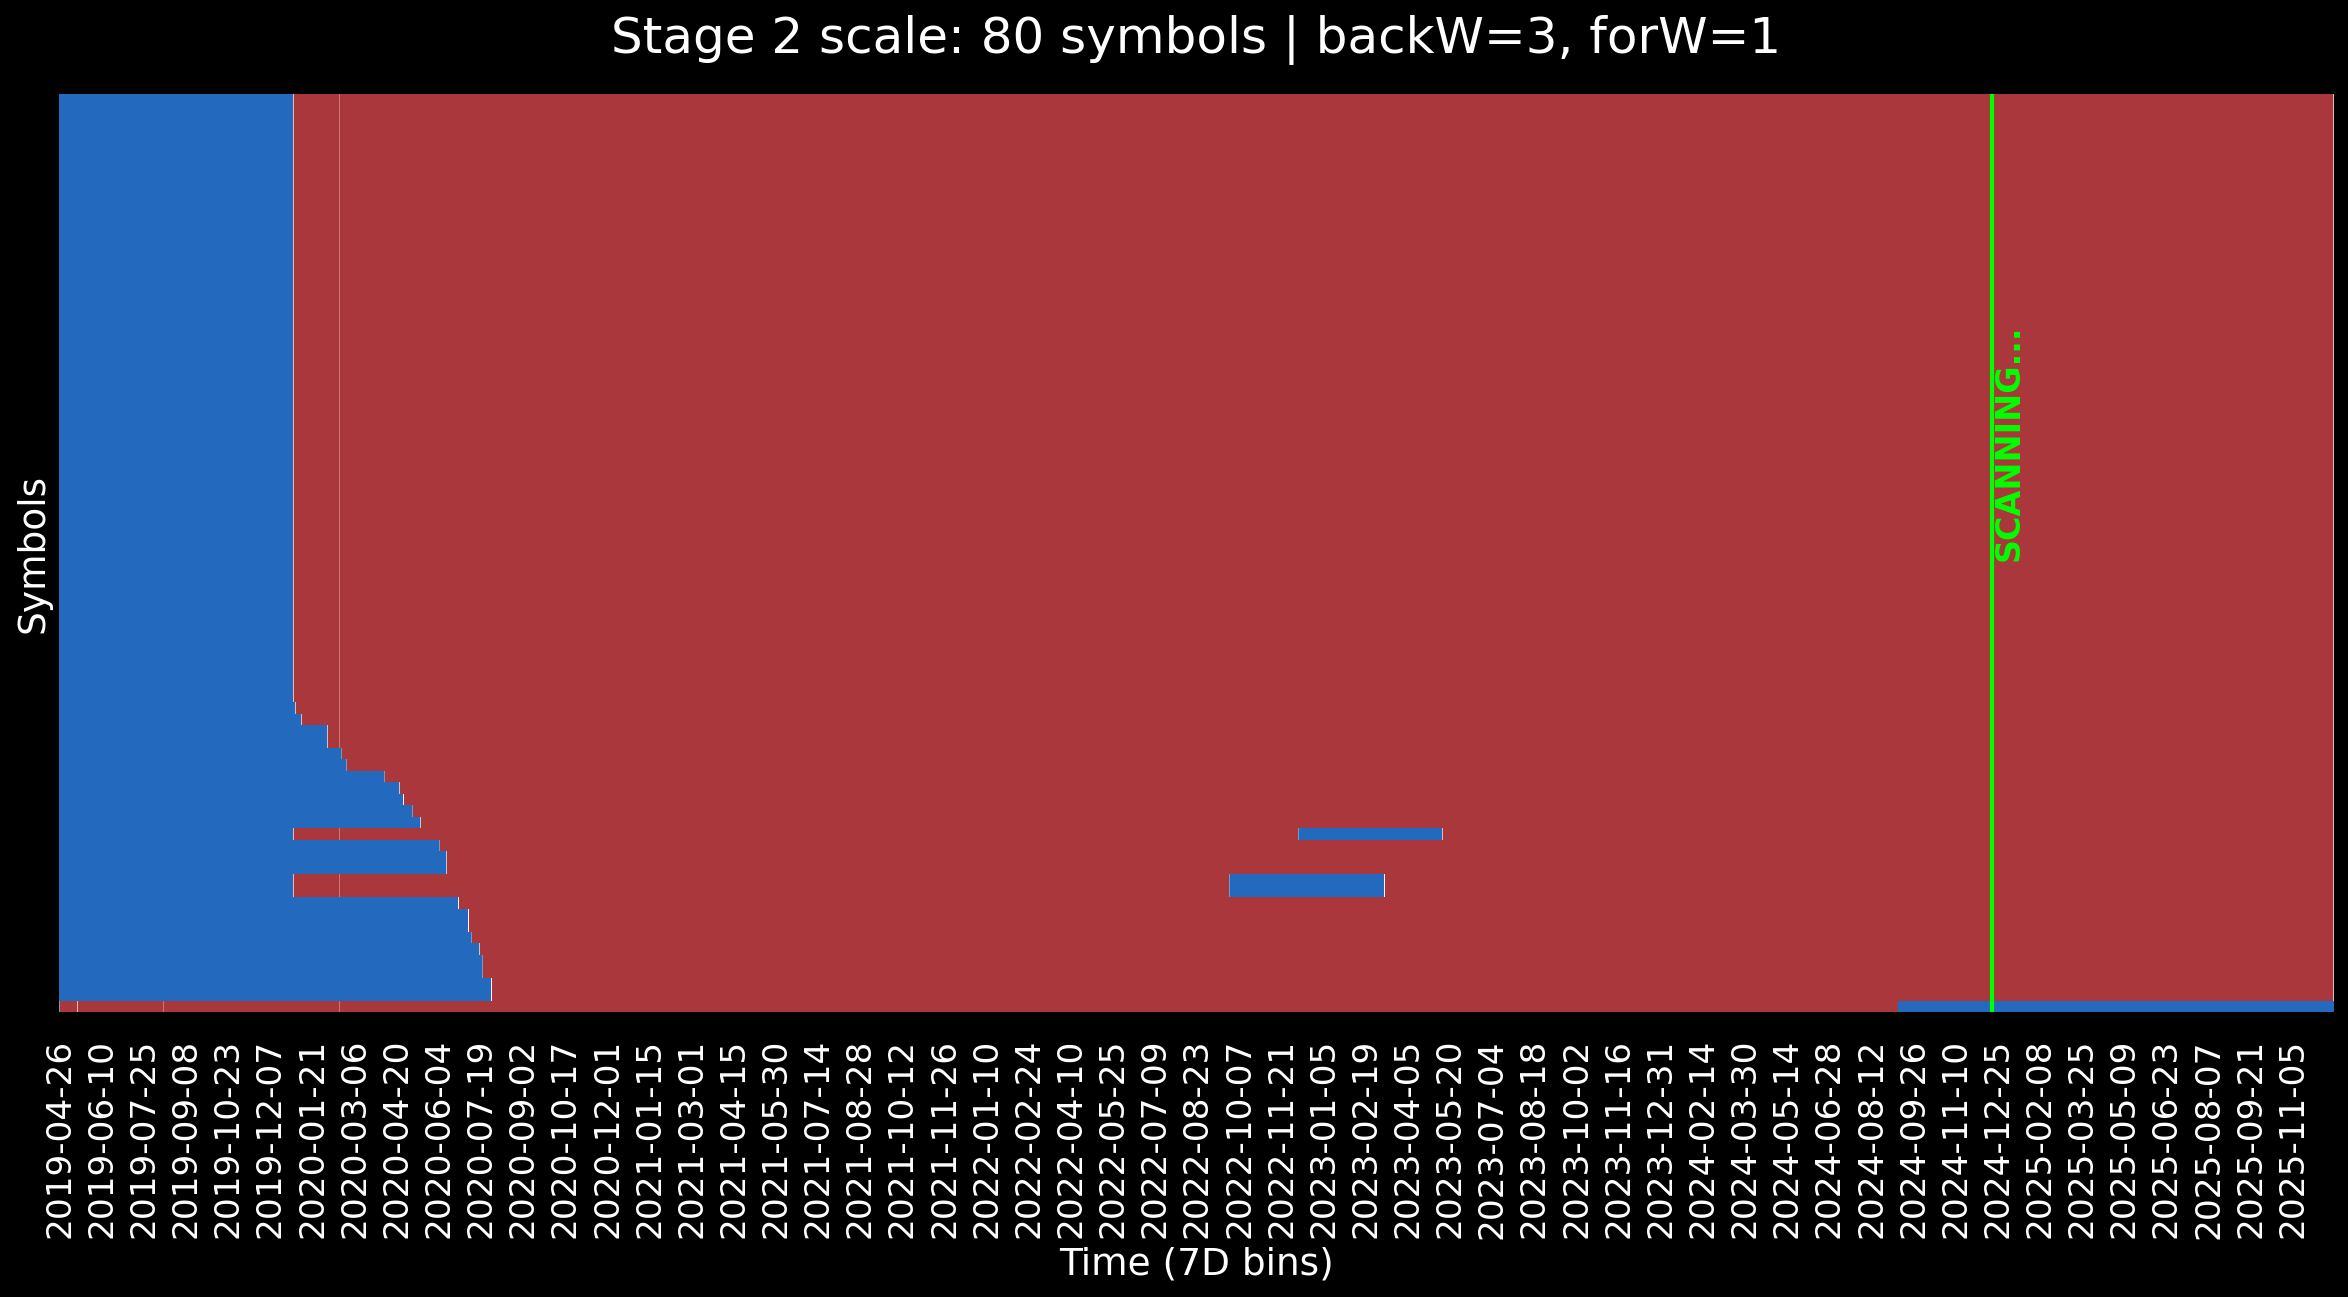

Recent candles with labels


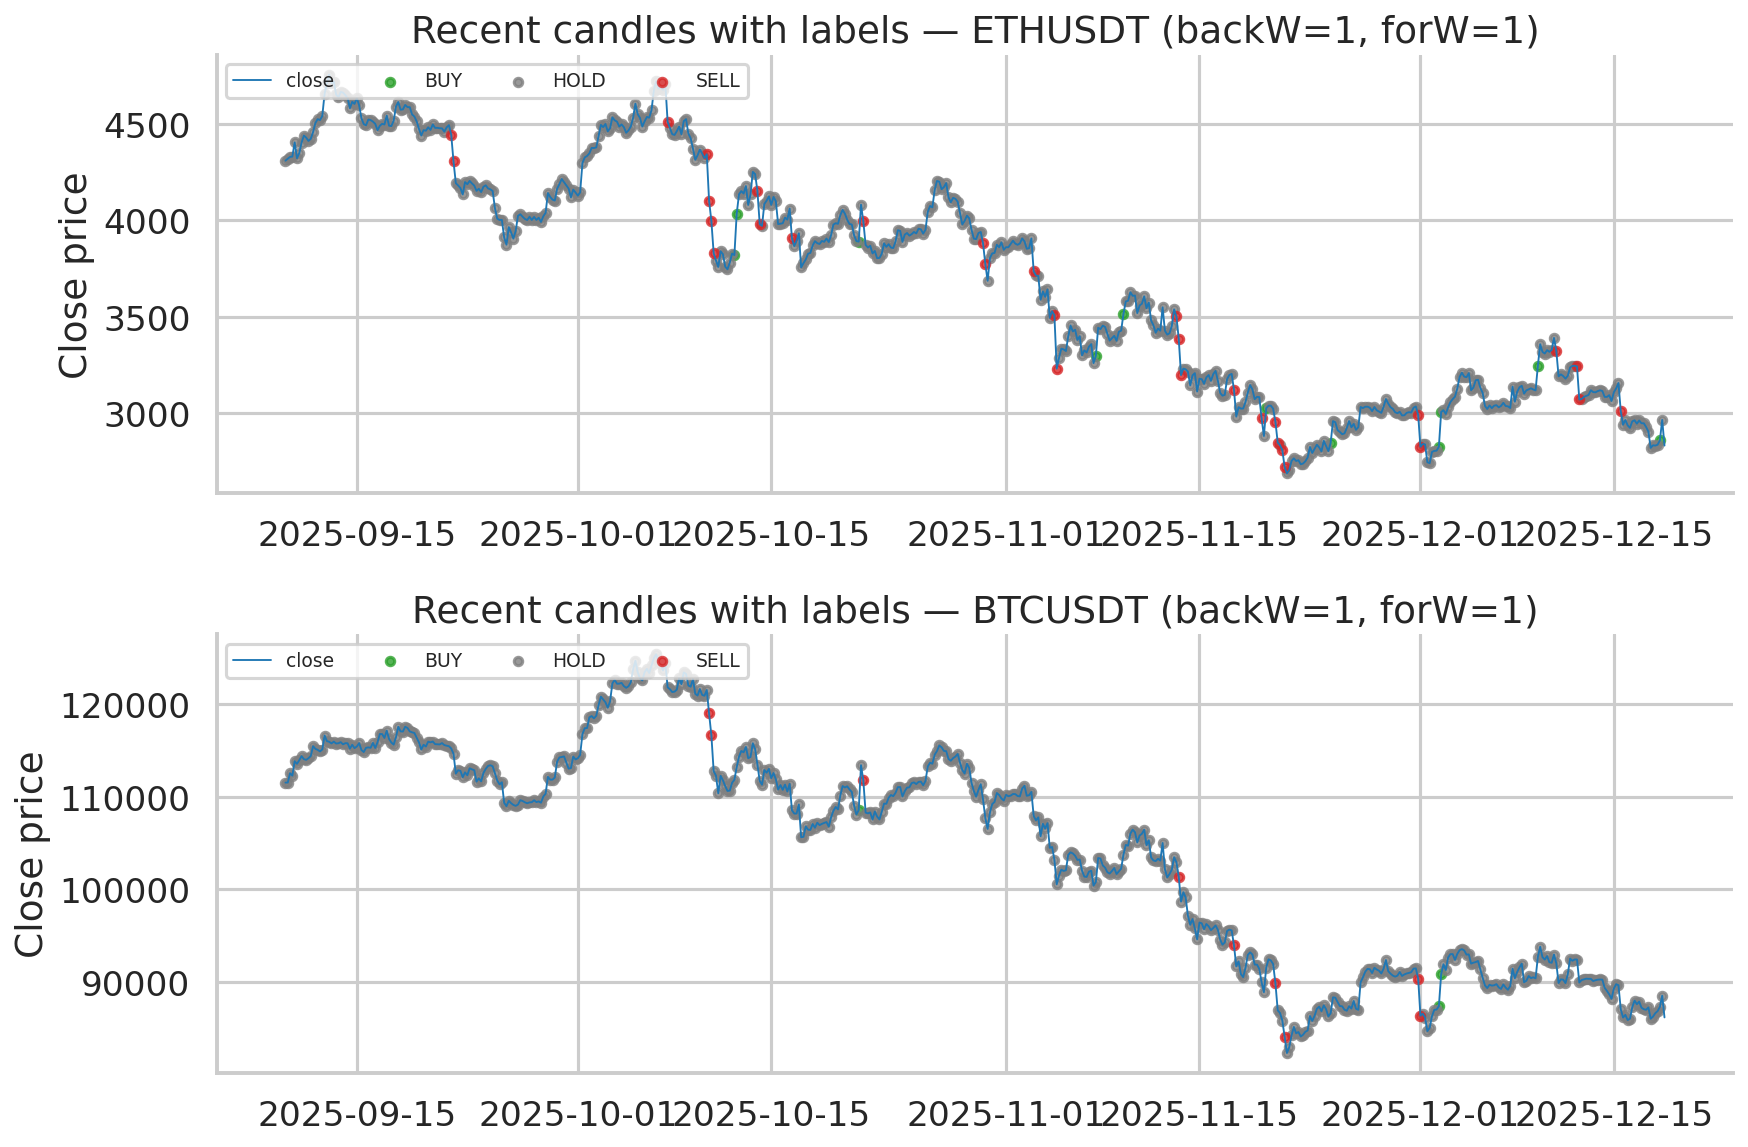

Label window examples


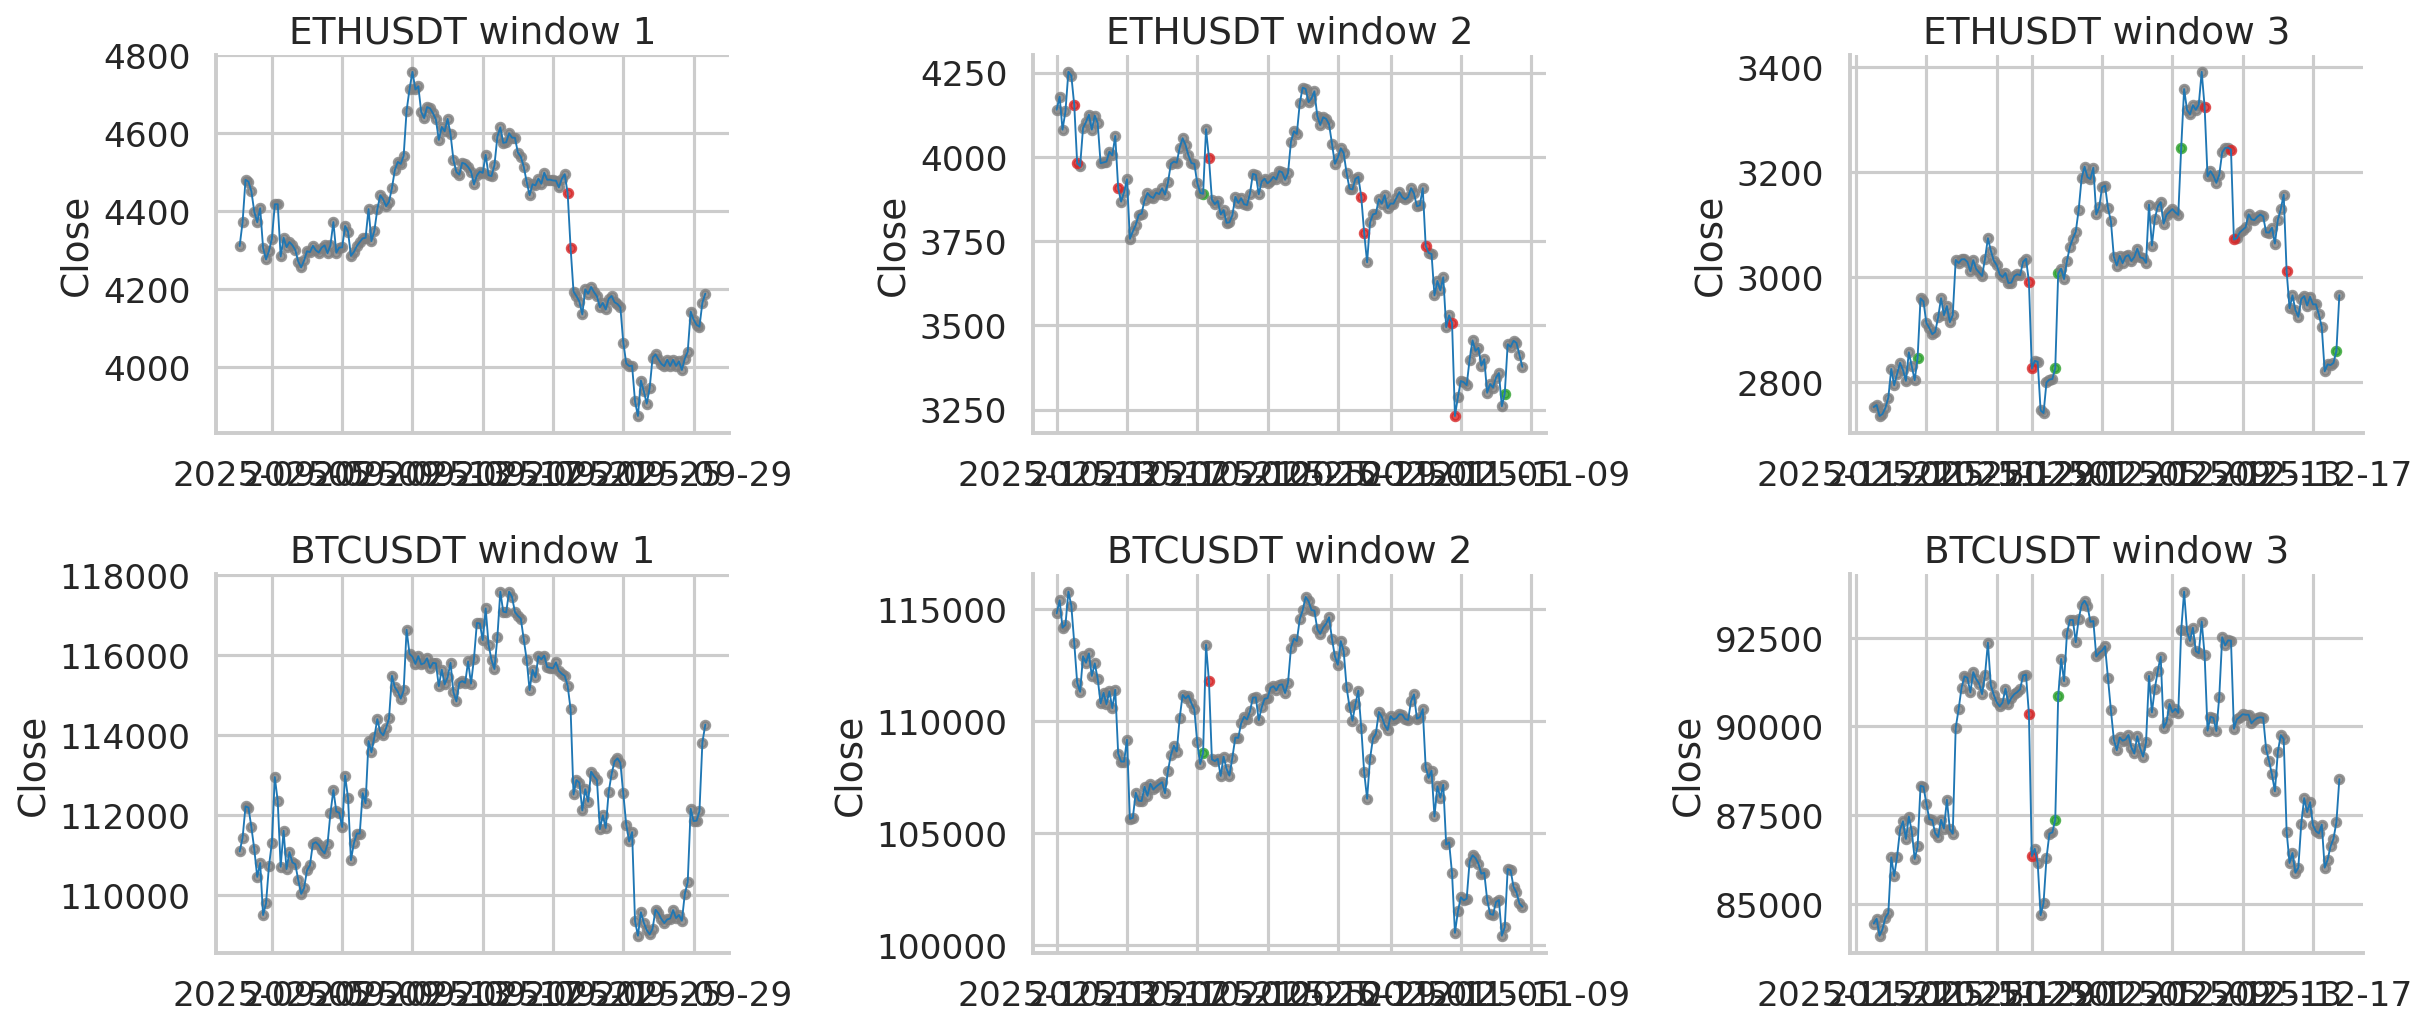

Missing chart: /home/kamil/binance-bot/data/charts_stage2/label_tape_recent.png
Missing chart: /home/kamil/binance-bot/data/charts_stage2/recent_label_mix.png
Extreme move timeline


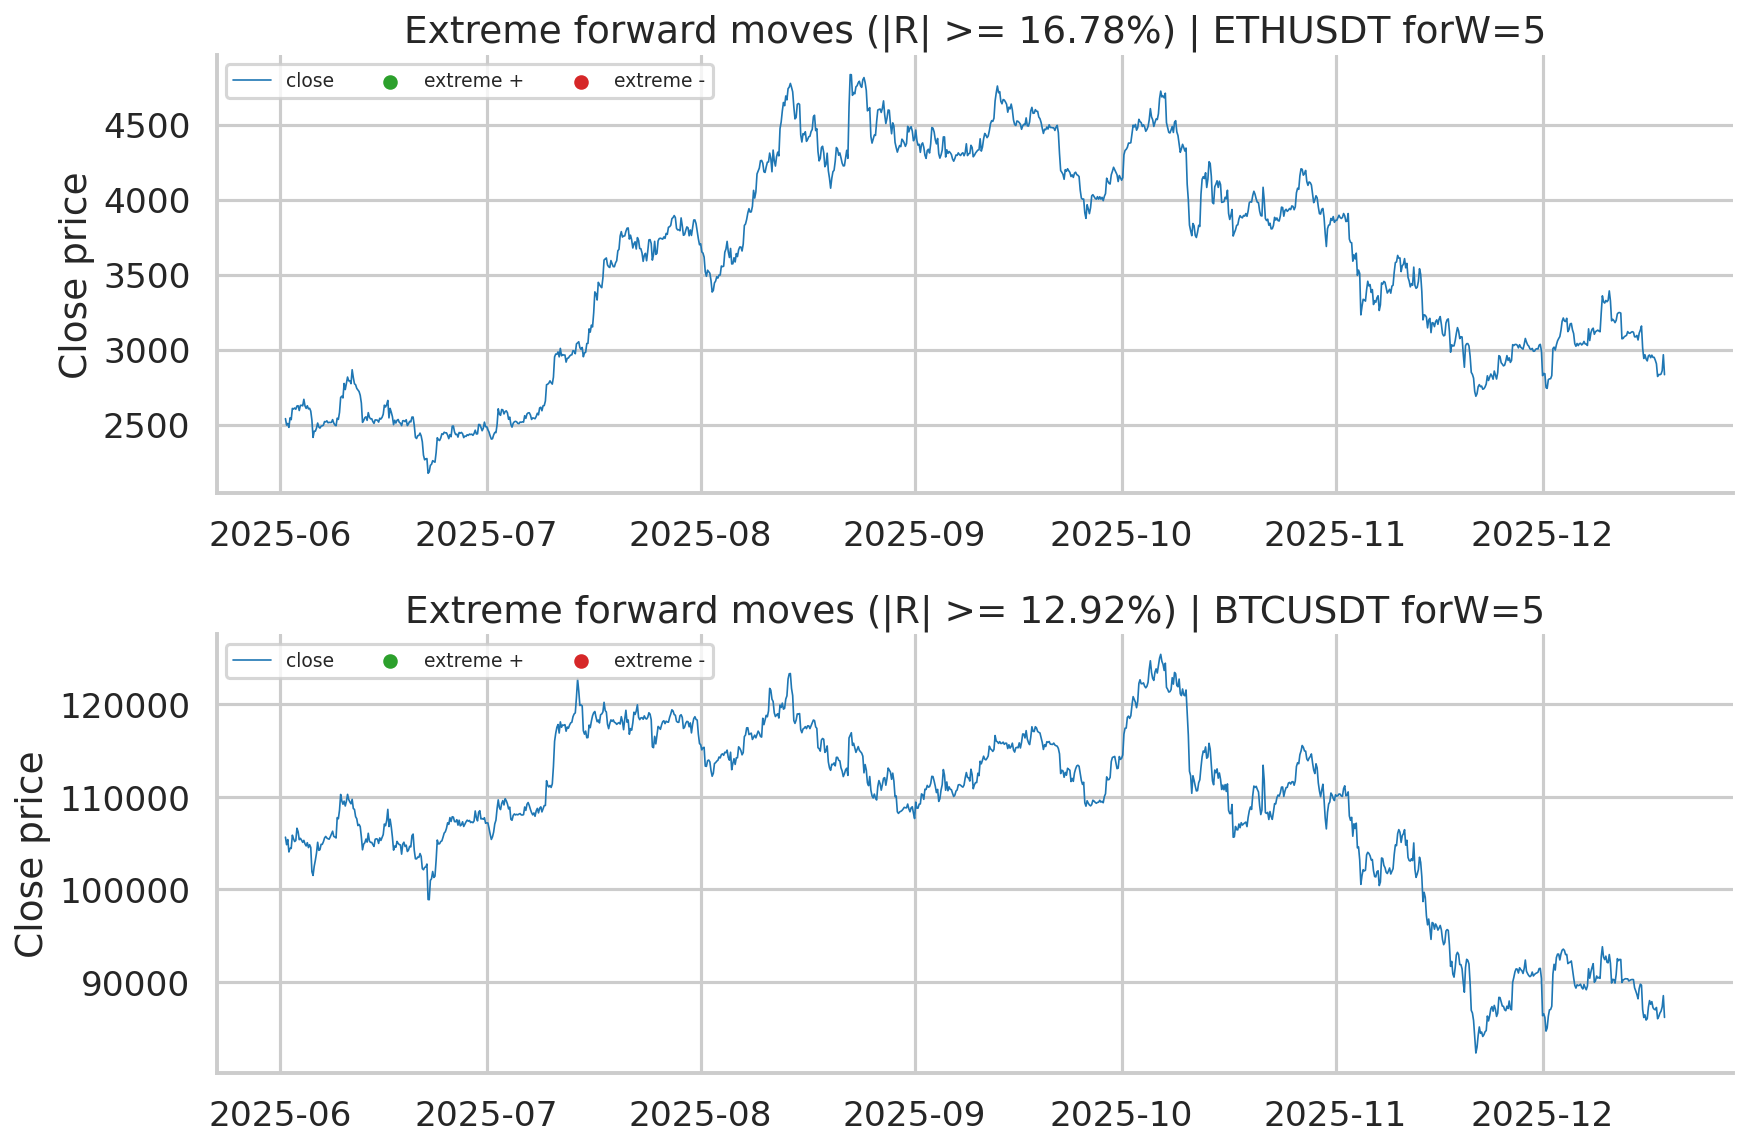

Extreme event rates


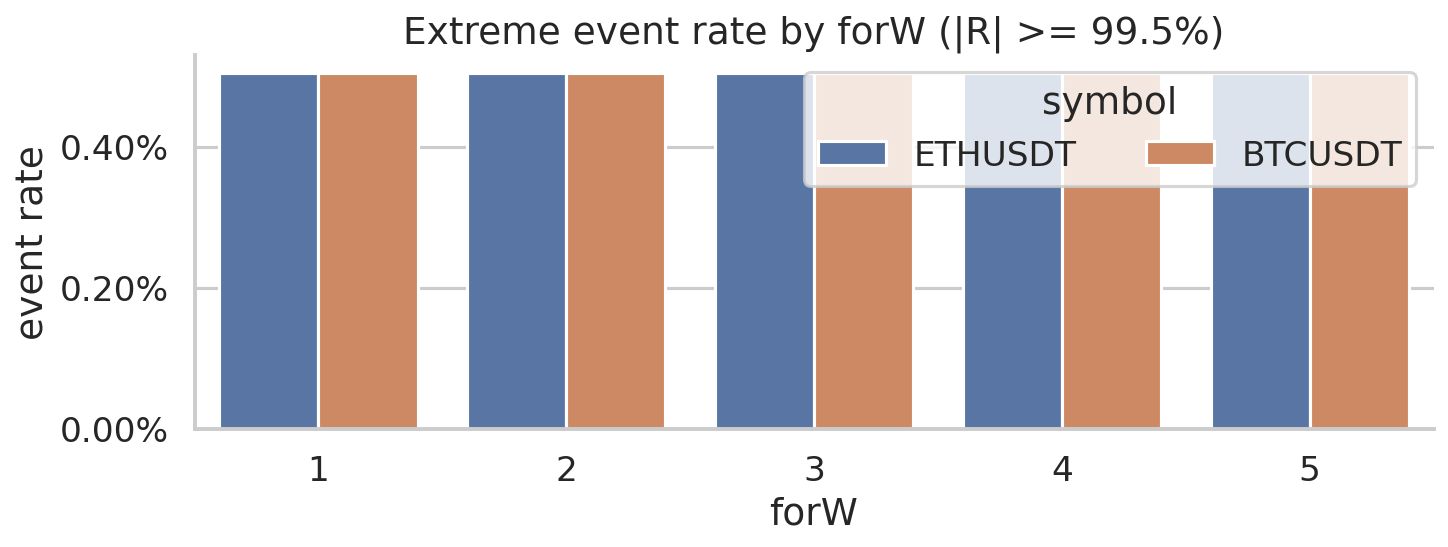

Tail percentiles


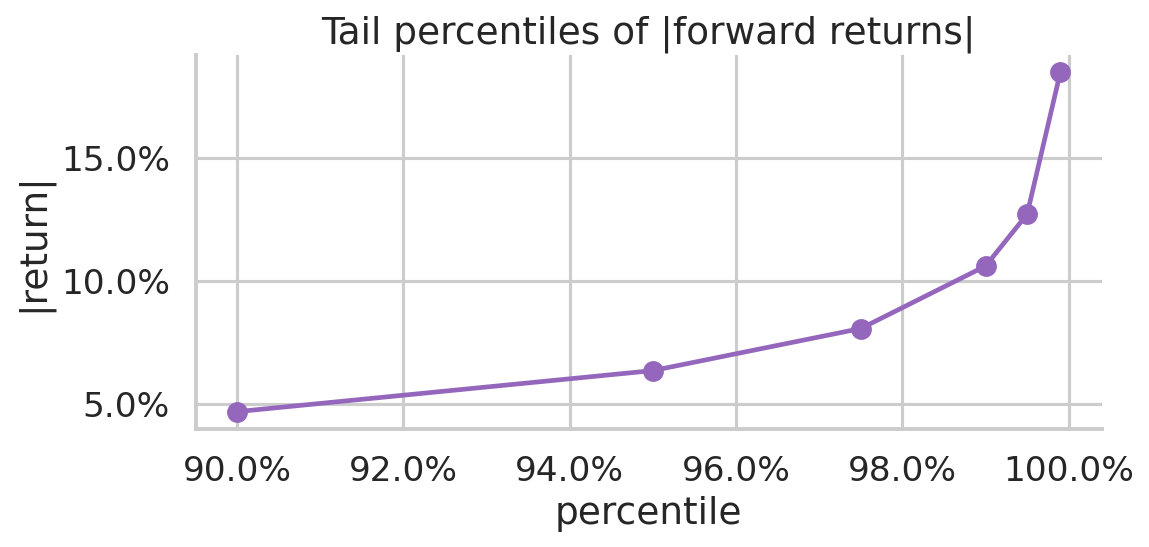

In [15]:
def show_chart(name: str, caption: str) -> None:
    path = OUTPUT_DIR / name
    if not path.exists():
        print(f"Missing chart: {path}")
        return
    if caption:
        print(caption)
    if HAS_IPY:
        display(Image(filename=str(path)))
    else:
        print(path)


charts = [
    ("stage2_label_mix_overview.png", "Stage 2 label mix overview"),
    ("data_availability_over_time.png", "Labeled rows over time"),
    ("hold_share_hist.png", "HOLD share distribution"),
    ("hold_share_by_window_violin.png", "HOLD share by window"),
    ("baseline_label_heatmaps.png", "BUY/HOLD/SELL heatmaps"),
    ("label_mix_top_symbols.png", "Label mix for top symbols"),
    ("alpha_percentile_sensitivity.png", "Alpha percentile sensitivity"),
    ("beta_percentile_sensitivity.png", "Beta percentile sensitivity"),
    ("forward_return_distributions.png", "Forward return distributions"),
    ("tail_curve_abs_returns.png", "Tail curve of |forward returns|"),
    ("visual_1_distribution.png", "Video visual: return distribution"),
    ("visual_2_logic.png", "Video visual: labeling logic"),
    ("visual_3_scale.png", "Video visual: Stage 2 scale"),
    ("recent_candles.png", "Recent candles with labels"),
    ("window_examples_stage2.png", "Label window examples"),
    ("label_tape_recent.png", "Label tape (recent window)"),
    ("recent_label_mix.png", "Recent label mix"),
    ("extreme_move_timeline.png", "Extreme move timeline"),
    ("extreme_event_rates.png", "Extreme event rates"),
    ("tail_percentiles.png", "Tail percentiles"),
]

for name, caption in charts:
    show_chart(name, caption)
